In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from keras.datasets import mnist
import matplotlib.pyplot as plt

In [3]:
#loading the data
#this data will be in form of numpy arrays
(X_train, y_train), (X_test, y_test) = mnist.load_data()
#print the shape
print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [4]:
#normalizing
X_train, X_test = X_train / 255.0, X_test / 255.0 #this scales the data to this[0, 1] range

#reshaping
X_train_reshaped = X_train.reshape(60000, 28, 28, 1)

In [5]:
#cnn architecture
model = models.Sequential([
    layers.Conv2D(28, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(56, (1, 1), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(56, (1, 1), activation='relu'),
    layers.Flatten(),
    layers.Dense(56, activation='relu'),
    layers.Dense(10, activation='softmax') 
])

model.summary()

c:\Users\USER\tfenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 28)     │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 28)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 56)     │         1,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 56)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 56)       │         3,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2016)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 56)             │       112,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,618 (463.35 KB)

 Trainable params: 118,618 (463.35 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#compiling the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), # used sparsecategorical cross entropy since 
              #my target labels are integers and it supports this, it is more efficient and there's no need for one-hot encoding
              metrics=['accuracy'])


In [7]:
#training the model
trained_model = model.fit(X_train, y_train, epochs=10, 
                    validation_data=(X_test, y_test))
print(trained_model)

Epoch 1/10


c:\Users\USER\tfenv\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.9394 - loss: 0.1973 - val_accuracy: 0.9777 - val_loss: 0.0694
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9801 - loss: 0.0640 - val_accuracy: 0.9834 - val_loss: 0.0486
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 12ms/step - accuracy: 0.9847 - loss: 0.0476 - val_accuracy: 0.9857 - val_loss: 0.0430
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9880 - loss: 0.0376 - val_accuracy: 0.9839 - val_loss: 0.0516
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9904 - loss: 0.0304 - val_accuracy: 0.9880 - val_loss: 0.0363
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9921 - loss: 0.0253 - val_accuracy: 0.9889 - val_loss: 0.0350
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9933 - loss: 0.0204 - val_accuracy: 0.9866 - val_loss: 0.0443
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9938 - loss: 0.01

The label is: 5


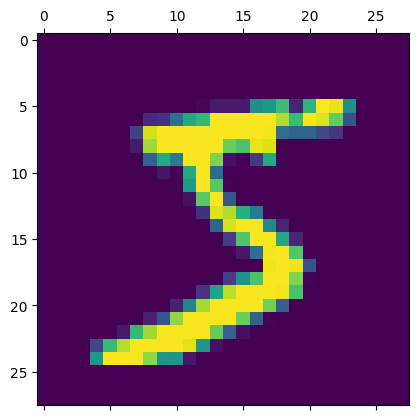

In [17]:
#visualizing
#input image of one training image
plt.matshow(X_train[0])
print(f"The label is: {y_train[0]}")